<a href="https://colab.research.google.com/github/Nicolas-Bernal/Simulacion-Estadistica/blob/main/Primer%20Corte/0_3_Algoritmo_Box_muller%2C_Masaglia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nicolas Bernal Rubio

## Simulacion Estadistica

# BOX - Muller

## El algoritmo de Box-Muller transforma dos variables aleatorias independientes distribuidas uniformemente en el intervalo $(0, 1)$ para generar un par de variables aleatorias independientes que siguen una distribución normal estándar $N(0, 1)$.

* a)  Generar $U_1,U_2 - N(0,1) $

* b)  Hacer $R = \sqrt-2ln(U_1), \theta = 2\pi U_2$

* c)  hacer $X = Rcos(\theta), Y = Rsen(\theta)$

* d)  $X - N(0,1), Y - N(0,1)$, ademas X y Y son independientes

In [4]:
install.packages("car")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’




In [ ]:
# algoritmo Box-Muller
library(car)

box_muller = function(nsim){
  x = rep(0,nsim)
  y = rep(0,nsim)

  for(i in 1:nsim){

    u1 = runif(nsim)
    u2 = runif(nsim)

    R = sqrt(-2*log(u1))
    theta = 2*pi*u2

    x[i] = R*cos(theta)
    y[i] = R*sin(theta)
  }
  return(list(x = x,y = y))
}

X_salida = box_muller(1000)$x

Y_salida = box_muller(1000)$y

[1] 703   9


	Shapiro-Wilk normality test

data:  X_salida
W = 0.99803, p-value = 0.2934


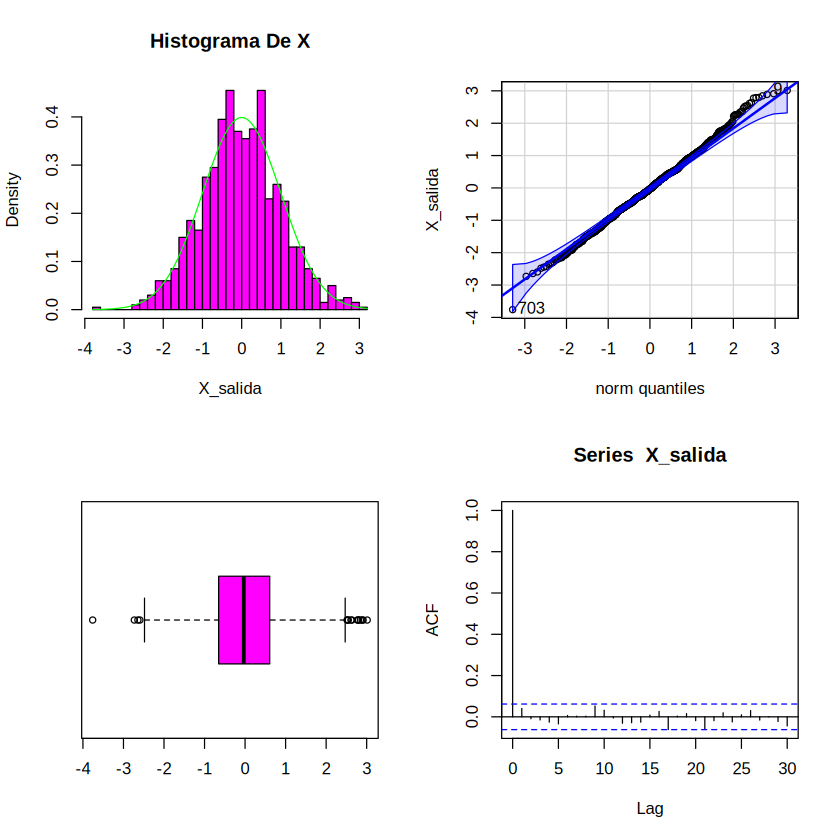

In [16]:
# Graficas y pruebas de X ~ N(0,1), Y ~ N(0,1)

par(mfrow = c(2,2))
hist(X_salida,freq = FALSE,breaks = "FD",col = "magenta",main = "Histograma De X")
curve(dnorm(x),add = TRUE,col = "green")
qqPlot(X_salida)
boxplot(X_salida,horizontal = TRUE,col = "magenta")
acf(X_salida)

shapiro.test(X_salida) #para mi semilla me da un p-value = 0.293 por lo que se acepta la hipotesis nula

[1] 976 780


	Shapiro-Wilk normality test

data:  Y_salida
W = 0.99754, p-value = 0.1388


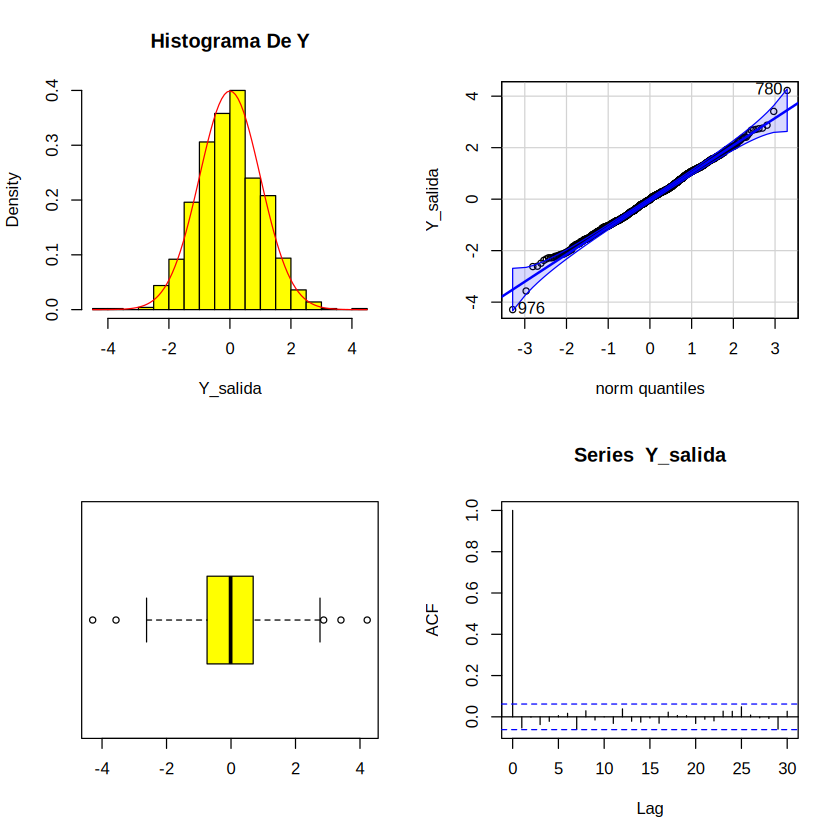

In [17]:
par(mfrow = c(2,2))
hist(Y_salida,freq = FALSE,breaks = "FD",col = "yellow",main = "Histograma De Y")
curve(dnorm(x),add = TRUE,col = "red")
qqPlot(Y_salida)
boxplot(Y_salida,horizontal = TRUE,col = "yellow")
acf(Y_salida)

shapiro.test(Y_salida) #para mi semilla me da un p-value = 0.1388 por lo que se acepta la hipotesis nula

## *Eficiencia Computacional*

In [ ]:
# system.time


tX = system.time(box_muller(1000)$X)
tY = system.time(box_muller(1000)$Y)
# eficiencia computacional comparando


t0 = proc.time()
box_muller(1000)$X
t1x = proc.time() - t0



t0 = proc.time()
box_muller(1000)$Y
t1y = proc.time() - t0

# comparacion proc vs system

tX
t1x

tY
t1y


# Masaglia


El **método de Marsaglia** (o transformación de *Marsaglia-Bray*) es una modificación del algoritmo de Box-Muller diseñada para evitar el cálculo de funciones trigonométricas ($\cos$ y $\sin$), las cuales son computacionalmente costosas.

### Intuición Matemática

En lugar de generar un ángulo $\theta$ directamente con $2\pi U_2$, Marsaglia utiliza un método de **aceptación y rechazo** en el círculo unitario:

1. Genera dos variables uniformes independientes $V_1, V_2 \sim \text{Unif}(-1, 1)$.
2. Calcula la distancia al cuadrado desde el origen: $S = V_1^2 + V_2^2$.
3. Si $S \ge 1$ o $S = 0$, se descarta el punto y se vuelve a intentar (aceptamos solo puntos dentro del círculo unitario de radio 1).
4. Dentro del círculo unitario, los cocientes $\frac{V_1}{\sqrt{S}}$ y $\frac{V_2}{\sqrt{S}}$ representan exactamente el coseno y seno de un ángulo uniforme.

Sustituyendo estas relaciones en la fórmula original de Box-Muller, se obtienen las expresiones finales:

$$Z_1 = V_1 \sqrt{\frac{-2 \ln(S)}{S}}$$

$$Z_2 = V_2 \sqrt{\frac{-2 \ln(S)}{S}}$$

In [26]:
# algoritmo de masaglia

masaglia = function(nsim){
  X = rep(0,nsim)
  Y = rep(0,nsim)

  for(i in 1:nsim){
    w = 2
    while ( w>1 || w==0){
      u1 = runif(1)
      u2 = runif(1)

      v1 = 2*u1-1
      v2 = 2*u2-1

      w = v1^2 + v2^2
    }
    c = sqrt((-2 * log(w)) / w)

    X[i] = c * v1
    Y[i] = c * v2
  }

  return(list(x = X, y = Y))
}

X = masaglia(2000)$x
Y = masaglia(2000)$y

[1]  203 1103


	Shapiro-Wilk normality test

data:  X
W = 0.99891, p-value = 0.2576


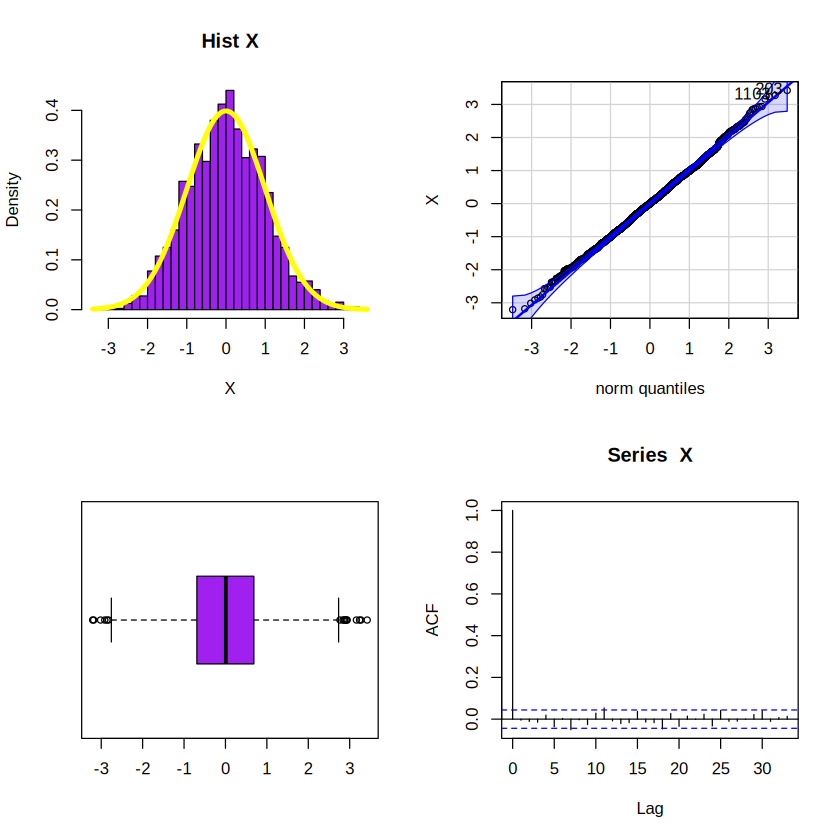

In [36]:
# graficos y pruebas

par(mfrow = c(2,2))
hist(X,freq = FALSE,breaks = "FD",col = "purple",main = "Hist X")
curve(dnorm(x),add = TRUE,col = "yellow",lwd = 4)
qqPlot(X)
boxplot(X,horizontal = TRUE,col = "purple")
acf(X)

shapiro.test(X)

[1] 599 615


	Shapiro-Wilk normality test

data:  Y
W = 0.99949, p-value = 0.9004


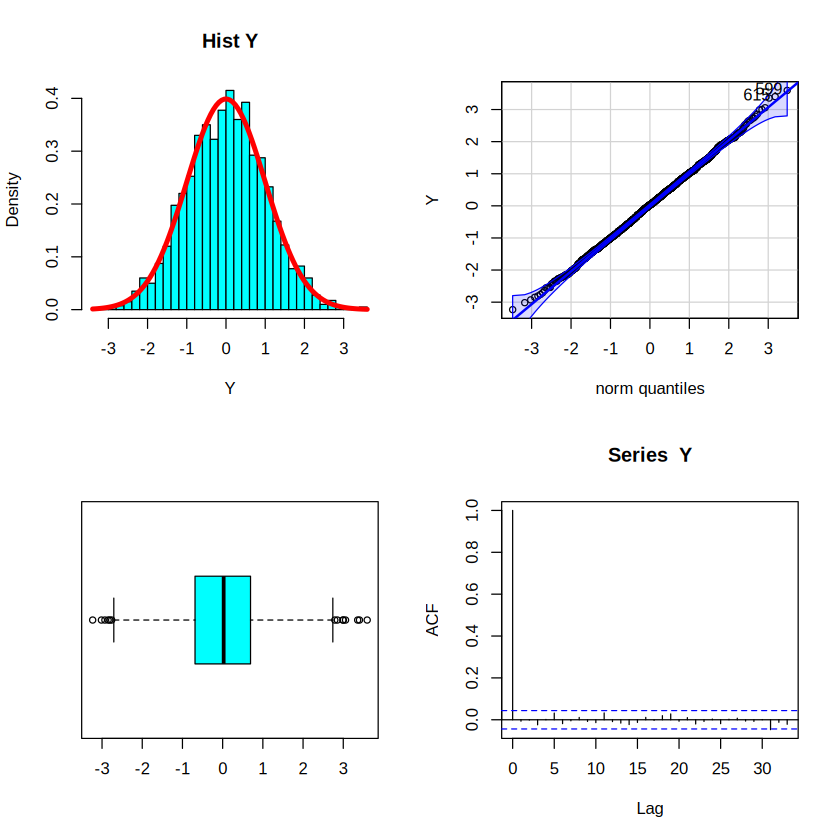

In [34]:
par(mfrow = c(2,2))
hist(Y,freq = FALSE,breaks = "FD",col = "cyan",main = "Hist Y")
curve(dnorm(x),add = TRUE,col = "red",lwd = 4)
qqPlot(Y)
boxplot(Y,horizontal = TRUE,col = "cyan")
acf(Y)

shapiro.test(Y)

## *Eficiencia Computacional*

In [ ]:
tX = system.time(masaglia(1000)$x)
tY = system.time(masaglia(1000)$y)
# eficiencia computacional comparando


t0 = proc.time()
masaglia(1000)$x
t1x = proc.time() - t0



t0 = proc.time()
masaglia(1000)$y
t1y = proc.time() - t0

# comparacion proc vs system

tX
t1x

tY
t1y